# The Wrong Politics: Sorting Mechanism Exploration

**Purpose:** Build the empirical foundation for testing whether welfare institutions sort economic disruption into solidarity vs. scapegoating.

**Core test:** Cross-level interaction — does the relationship between individual RTI (automation exposure) and political attitudes vary by country-level welfare institutional characteristics?

**Data:** ESS waves 1–9 (CSV), ISCO-08 task scores, populist party crosswalk, CPDS/SIWE welfare indicators.

---

## 0. Setup & Data Inventory

### Critical corrections from MEMORY.md (read before coding):

1. **Task score column is `task`** — NOT `rtask` or `nrtask`. Every old reference is wrong.
2. **ESS waves 1–5 use `iscoco` (ISCO-88)**, waves 6–9 use `isco08` (ISCO-08). Direct RTI merge only works for waves 6–9.
3. **Waves 1–5 need two-step crosswalk** via `correspondence.dta` (ISCO-88 → ISCO-08). Many-to-many — deduplicate or get ~190% row inflation.
4. **Populist crosswalk is semicolon-delimited** — `sep=';'`.
5. **`hinctnta` absent waves 1–3** — use `hinctnt` for those waves.
6. **ESS CSVs may need encoding fallback**: utf-8 → latin-1 → cp1252.
7. **ESS is repeated cross-sections**, NOT panel data.
8. **`posit_income_change` is NOT in this repo** — Cicollini constructs it from EU-SILC separately.

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Paths ---
ROOT = Path(r'C:\Users\PKF715\Documents\claude_repos\Research_Master')
ESS_DIR = ROOT / 'data' / 'raw' / 'ESS_csv'
TASK_FILE = ROOT / 'data' / 'raw' / 'shared_isco_task_scores' / 'isco08_3d-task3.csv'
CROSSWALK_FILE = ROOT / 'data' / 'raw' / 'langenkamp_2022' / 'ess_populist_crosswalk.csv'
CPDS_FILE = ROOT / 'data' / 'raw' / 'baccini_2024' / 'Replication V3' / 'Data' / 'Raw Data' / 'CPDS_Aug_2020.dta'
SIWE_FILE = ROOT / 'data' / 'raw' / 'siwe_2017' / 'SIWE_betaMay2017.dta'
GINGRICH_CTX = ROOT / 'data' / 'raw' / 'gingrich_2019' / 'gingrich - RP_Context_Data.dta'
ISCO_CROSSWALK = ROOT / 'data' / 'raw' / 'kurer_2020_declining_middle' / 'replication_files' / 'replication_files' / 'correspondence.dta'

# --- Plot style ---
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


In [2]:
# --- Data inventory: list all ESS CSV files ---
ess_files = sorted(ESS_DIR.glob('*/ESS*.csv'))
print(f'Found {len(ess_files)} ESS CSV files:\n')
for f in ess_files:
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.parent.name}/{f.name}  ({size_mb:.1f} MB)')

# Verify key auxiliary files exist
for label, path in [('Task scores', TASK_FILE), ('Populist crosswalk', CROSSWALK_FILE),
                     ('CPDS', CPDS_FILE), ('SIWE', SIWE_FILE)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'\n{label}: {status} — {path.name}')

Found 9 ESS CSV files:

  ESS1e06_7/ESS1e06_7.csv  (50.9 MB)
  ESS2e03_6/ESS2e03_6.csv  (61.5 MB)
  ESS3e03_7/ESS3e03_7.csv  (48.4 MB)
  ESS4e04_6/ESS4e04_6.csv  (71.4 MB)
  ESS5e03_5/ESS5e03_5.csv  (69.9 MB)
  ESS6e02_6/ESS6e02_6.csv  (65.3 MB)
  ESS7e02_3/ESS7e02_3.csv  (49.4 MB)
  ESS8e02_3/ESS8e02_3.csv  (47.7 MB)
  ESS9e03_2/ESS9e03_2.csv  (58.9 MB)

Task scores: OK — isco08_3d-task3.csv

Populist crosswalk: OK — ess_populist_crosswalk.csv

CPDS: OK — CPDS_Aug_2020.dta

SIWE: OK — SIWE_betaMay2017.dta


---
## 1. Load & Profile ESS Data

**Strategy:** Load all 9 waves, keeping only the variables we need. This keeps memory manageable.

**Key distinction:**
- Waves 1–5: `iscoco` (ISCO-88) — needs crosswalk for RTI
- Waves 6–9: `isco08` (ISCO-08) — direct RTI merge
- Waves 4 & 8: have welfare attitudes module (deservingness items for H3)

In [3]:
def load_ess_csv(filepath, usecols=None):
    """Load ESS CSV with multi-encoding fallback per MEMORY.md."""
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(filepath, encoding=enc, usecols=usecols, low_memory=False)
            return df
        except (UnicodeDecodeError, ValueError):
            continue
    raise ValueError(f'Could not read {filepath} with any encoding')


# --- Define variables to keep ---
# Core identifiers
ID_VARS = ['essround', 'cntry', 'idno']

# Occupation (varies by wave)
ISCO_VARS = ['isco08', 'iscoco']  # will keep whichever exists

# DVs: exclusionary attitudes
DV_EXCLUSION = ['imwbcnt', 'imueclt', 'imbgeco']  # immigration attitudes (0-10)

# DVs: solidaristic attitudes
DV_SOLIDARITY = ['gincdif']  # gov should reduce income differences (1-5)

# DVs: trust (mediator/control)
DV_TRUST = ['trstprl', 'trstplt']

# Deservingness items (ESS4 and ESS8 only — welfare module)
DV_DESERVING = ['sbstrec', 'sbprvpv', 'sbbsntx', 'uentrjb']

# Vulnerability measures
VULN_VARS = ['emplno', 'uemp3m', 'uemp12m']

# Controls
CONTROL_VARS = ['agea', 'gndr', 'eisced', 'eduyrs', 'hinctnta', 'hinctnt',
                'domicil', 'lrscale']

# Party vote variables will be loaded separately (country-specific names)

ALL_CANDIDATE_VARS = (ID_VARS + ISCO_VARS + DV_EXCLUSION + DV_SOLIDARITY +
                      DV_TRUST + DV_DESERVING + VULN_VARS + CONTROL_VARS)

print(f'Will attempt to load {len(ALL_CANDIDATE_VARS)} candidate variables per wave.')
print('(Not all will be present in every wave — that is expected.)')

Will attempt to load 26 candidate variables per wave.
(Not all will be present in every wave — that is expected.)


In [4]:
# --- Load all ESS waves, keeping only available candidate vars ---
waves = {}
wave_summaries = []

for fpath in ess_files:
    # Read header to find which candidate vars are present
    header = pd.read_csv(fpath, nrows=0, encoding='latin-1').columns.tolist()
    available = [v for v in ALL_CANDIDATE_VARS if v in header]
    
    # Also grab all prtvt* columns for party vote
    prtvt_cols = [c for c in header if c.startswith('prtvt')]
    cols_to_load = available + prtvt_cols
    
    df = load_ess_csv(fpath, usecols=cols_to_load)
    round_num = int(df['essround'].iloc[0])
    waves[round_num] = df
    
    # Determine ISCO type
    isco_type = 'isco08' if 'isco08' in df.columns else ('iscoco' if 'iscoco' in df.columns else 'NONE')
    
    wave_summaries.append({
        'wave': round_num,
        'n_obs': len(df),
        'n_countries': df['cntry'].nunique(),
        'countries': ', '.join(sorted(df['cntry'].unique())),
        'isco_type': isco_type,
        'has_imwbcnt': 'imwbcnt' in df.columns,
        'has_gincdif': 'gincdif' in df.columns,
        'has_sbstrec': 'sbstrec' in df.columns,
        'has_hinctnta': 'hinctnta' in df.columns,
        'n_prtvt_vars': len(prtvt_cols),
    })
    print(f'Wave {round_num}: {len(df):,} obs, {df["cntry"].nunique()} countries, ISCO={isco_type}')

print(f'\nTotal observations across all waves: {sum(len(df) for df in waves.values()):,}')

Wave 1: 42,359 obs, 22 countries, ISCO=iscoco
Wave 2: 47,537 obs, 25 countries, ISCO=iscoco
Wave 3: 43,000 obs, 23 countries, ISCO=iscoco
Wave 4: 56,752 obs, 29 countries, ISCO=iscoco
Wave 5: 52,458 obs, 27 countries, ISCO=iscoco
Wave 6: 54,673 obs, 29 countries, ISCO=isco08
Wave 7: 40,185 obs, 21 countries, ISCO=isco08
Wave 8: 44,387 obs, 23 countries, ISCO=isco08
Wave 9: 49,519 obs, 29 countries, ISCO=isco08

Total observations across all waves: 430,870


In [5]:
# --- Variable availability matrix ---
summary_df = pd.DataFrame(wave_summaries).set_index('wave').sort_index()
display(summary_df[['n_obs', 'n_countries', 'isco_type', 'has_imwbcnt',
                     'has_gincdif', 'has_sbstrec', 'has_hinctnta', 'n_prtvt_vars']])

print('\n--- Key variable availability ---')
print('imwbcnt (anti-immigration): ALL waves ✓' if summary_df['has_imwbcnt'].all()
      else f'imwbcnt missing in waves: {list(summary_df[~summary_df["has_imwbcnt"]].index)}')
print('gincdif (redistribution): ALL waves ✓' if summary_df['has_gincdif'].all()
      else f'gincdif missing in waves: {list(summary_df[~summary_df["has_gincdif"]].index)}')
print(f'sbstrec (deservingness): waves {list(summary_df[summary_df["has_sbstrec"]].index)} only')
print(f'isco08 (direct RTI merge): waves {list(summary_df[summary_df["isco_type"]=="isco08"].index)}')
print(f'iscoco (needs crosswalk): waves {list(summary_df[summary_df["isco_type"]=="iscoco"].index)}')

,n_obs,n_countries,isco_type,has_imwbcnt,has_gincdif,has_sbstrec,has_hinctnta,n_prtvt_vars
wave,,,,,,,,
1,42359,22,iscoco,True,True,False,False,21
2,47537,25,iscoco,True,True,False,False,25
3,43000,23,iscoco,True,True,False,False,24
4,56752,29,iscoco,True,True,True,True,29
5,52458,27,iscoco,True,True,False,True,25
6,54673,29,isco08,True,True,False,True,27
7,40185,21,isco08,True,True,False,True,19
8,44387,23,isco08,True,True,True,True,21
9,49519,29,isco08,True,True,False,True,27



--- Key variable availability ---
imwbcnt (anti-immigration): ALL waves ✓
gincdif (redistribution): ALL waves ✓
sbstrec (deservingness): waves [4, 8] only
isco08 (direct RTI merge): waves [6, 7, 8, 9]
iscoco (needs crosswalk): waves [1, 2, 3, 4, 5]


In [6]:
# --- Detailed variable availability: wave × variable ---
key_vars = ['imwbcnt', 'imueclt', 'imbgeco', 'gincdif', 'trstprl', 'trstplt',
            'sbstrec', 'sbprvpv', 'sbbsntx', 'uentrjb',
            'emplno', 'uemp3m', 'uemp12m',
            'agea', 'gndr', 'eisced', 'eduyrs', 'hinctnta', 'hinctnt',
            'domicil', 'lrscale']

avail_matrix = pd.DataFrame(
    {w: {v: v in waves[w].columns for v in key_vars} for w in sorted(waves.keys())}
).T
avail_matrix.index.name = 'wave'

# Display with checkmarks
display(avail_matrix.replace({True: '✓', False: '—'}))

,imwbcnt,imueclt,imbgeco,gincdif,trstprl,trstplt,sbstrec,sbprvpv,sbbsntx,uentrjb,...,uemp3m,uemp12m,agea,gndr,eisced,eduyrs,hinctnta,hinctnt,domicil,lrscale
wave,,,,,,,,,,,,,,,,,,,,,
1,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,—,✓,✓,✓
2,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,—,✓,✓,✓
3,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,—,✓,✓,✓
4,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓
5,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓
6,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓
7,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓
8,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓
9,✓,✓,✓,✓,✓,✓,—,—,—,—,...,✓,✓,✓,✓,✓,✓,✓,—,✓,✓


### Decision point: which waves to use?

**For the main analysis (H1 & H2):** Waves 6–9 give us `isco08` for direct RTI merge plus `imwbcnt` and `gincdif`. This is the cleanest path.

**For H3 (mediation through deservingness):** Only waves 4 and 8 have `sbstrec`, `sbprvpv`, etc. Wave 8 has `isco08` — this is our best bet for H3.

**For maximum sample size:** We could include waves 1–5 using the ISCO-88 → ISCO-08 crosswalk, but MEMORY.md warns about many-to-many inflation. We'll start with waves 6–9 and note the extension.

**Proceeding with waves 6–9 as the primary analysis sample.**

In [7]:
# --- Stack waves 6-9 into primary analysis dataset ---
primary_waves = [6, 7, 8, 9]
dfs = []
for w in primary_waves:
    df = waves[w].copy()
    dfs.append(df)

ess = pd.concat(dfs, ignore_index=True)
print(f'Primary sample (waves 6-9): {len(ess):,} observations')
print(f'Countries: {ess["cntry"].nunique()}')
print(f'Waves: {sorted(ess["essround"].unique())}')
print(f'\nCountry list: {sorted(ess["cntry"].unique())}')

Primary sample (waves 6-9): 188,764 observations
Countries: 34
Waves: [np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Country list: ['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'RU', 'SE', 'SI', 'SK', 'UA', 'XK']


---
## 2. Construct Automation Exposure (RTI)

**Merge logic (from MEMORY.md):**
1. Task score file column is `task` (NOT `rtask`/`nrtask`)
2. ESS `isco08` is 4-digit; task file is 3-digit
3. Truncate ESS codes: `isco08 // 10` BEFORE merging
4. Expect ~70-80% match rate. If <50%, something is wrong.

In [8]:
# --- Load and verify task scores ---
tasks = pd.read_csv(TASK_FILE)
print(f'Task score file: {tasks.shape[0]} rows, {tasks.shape[1]} columns')
print(f'Columns: {list(tasks.columns)}')
task_col_check = 'task' in tasks.columns
print(f"Verification: column is task = {task_col_check}")  # MEMORY.md correction
print(f'Range of task scores: [{tasks["task"].min()}, {tasks["task"].max()}]')
print(f'Mean: {tasks["task"].mean():.2f}, SD: {tasks["task"].std():.2f}')
print(f'\nFirst 10 rows:')
display(tasks.head(10))

Task score file: 125 rows, 2 columns
Columns: ['isco08_3d', 'task']
Verification: column is task = True
Range of task scores: [1, 3]
Mean: 1.76, SD: 0.78

First 10 rows:


,isco08_3d,task
0,11,2
1,111,1
2,112,1
3,121,1
4,122,1
5,131,1
6,132,1
7,133,1
8,134,1
9,141,1


In [9]:
# --- Merge RTI onto ESS ---
# Step 1: Truncate 4-digit ISCO-08 to 3-digit
# Filter out invalid ISCO codes first (negatives are ESS missing codes)
ess['isco08_raw'] = ess['isco08'].copy()
ess['isco08_valid'] = pd.to_numeric(ess['isco08'], errors='coerce')
ess.loc[ess['isco08_valid'] < 0, 'isco08_valid'] = np.nan  # ESS uses negative codes for missing

# Truncate to 3-digit
ess['isco08_3d'] = (ess['isco08_valid'] // 10).astype('Int64')  # nullable int

print(f'ISCO-08 availability:')
print(f'  Total observations: {len(ess):,}')
print(f'  Valid ISCO-08 codes: {ess["isco08_valid"].notna().sum():,} ({ess["isco08_valid"].notna().mean():.1%})')
print(f'  Valid 3-digit codes: {ess["isco08_3d"].notna().sum():,}')
print(f'  Unique 3-digit codes in ESS: {ess["isco08_3d"].dropna().nunique()}')
print(f'  Unique 3-digit codes in task file: {tasks["isco08_3d"].nunique()}')

ISCO-08 availability:
  Total observations: 188,764
  Valid ISCO-08 codes: 188,764 (100.0%)
  Valid 3-digit codes: 188,764
  Unique 3-digit codes in ESS: 186
  Unique 3-digit codes in task file: 125


In [10]:
# Step 2: Merge
n_before = len(ess)
ess = ess.merge(tasks[['isco08_3d', 'task']], on='isco08_3d', how='left')
n_after = len(ess)

# Validate: no row inflation
assert n_before == n_after, f'ROW INFLATION: {n_before} → {n_after}'

# Match rate
has_isco = ess['isco08_valid'].notna()
has_task = ess['task'].notna()
overall_match = has_task.mean()
conditional_match = has_task[has_isco].mean()

print(f'RTI merge results:')
print(f'  Overall match rate: {overall_match:.1%} (includes people without ISCO codes)')
print(f'  Match rate among those WITH ISCO codes: {conditional_match:.1%}')
print(f'  N with RTI scores: {has_task.sum():,}')

if conditional_match < 0.50:
    print('\n⚠️ WARNING: Match rate <50% among ISCO-coded respondents. Something may be wrong.')
elif conditional_match < 0.70:
    print('\n⚠️ NOTE: Match rate 50-70%. Acceptable but worth investigating unmatched codes.')
else:
    print('\n✓ Match rate looks good.')

RTI merge results:
  Overall match rate: 87.8% (includes people without ISCO codes)
  Match rate among those WITH ISCO codes: 87.8%
  N with RTI scores: 165,667

✓ Match rate looks good.


In [11]:
# --- Match rate by country and wave ---
match_by_cw = (ess[has_isco]
    .groupby(['essround', 'cntry'])['task']
    .agg(['count', lambda x: x.notna().mean()])
)
match_by_cw.columns = ['n_with_isco', 'match_rate']
match_by_cw = match_by_cw.reset_index()

# Show countries with low match rates
low_match = match_by_cw[match_by_cw['match_rate'] < 0.6]
if len(low_match) > 0:
    print(f'Countries × waves with <60% match rate ({len(low_match)} cases):')
    display(low_match.sort_values('match_rate').head(20))
else:
    print('All country × wave combinations have ≥60% match rate. ✓')

# Summary by wave
print('\nMatch rate by wave:')
print(ess[has_isco].groupby('essround')['task'].apply(lambda x: f'{x.notna().mean():.1%}'))

Countries × waves with <60% match rate (2 cases):


,essround,cntry,n_with_isco,match_rate
28,6,XK,588,0.454054
93,9,ME,681,0.567500



Match rate by wave:
essround
6    86.8%
7    88.4%
8    87.9%
9    88.1%
Name: task, dtype: object


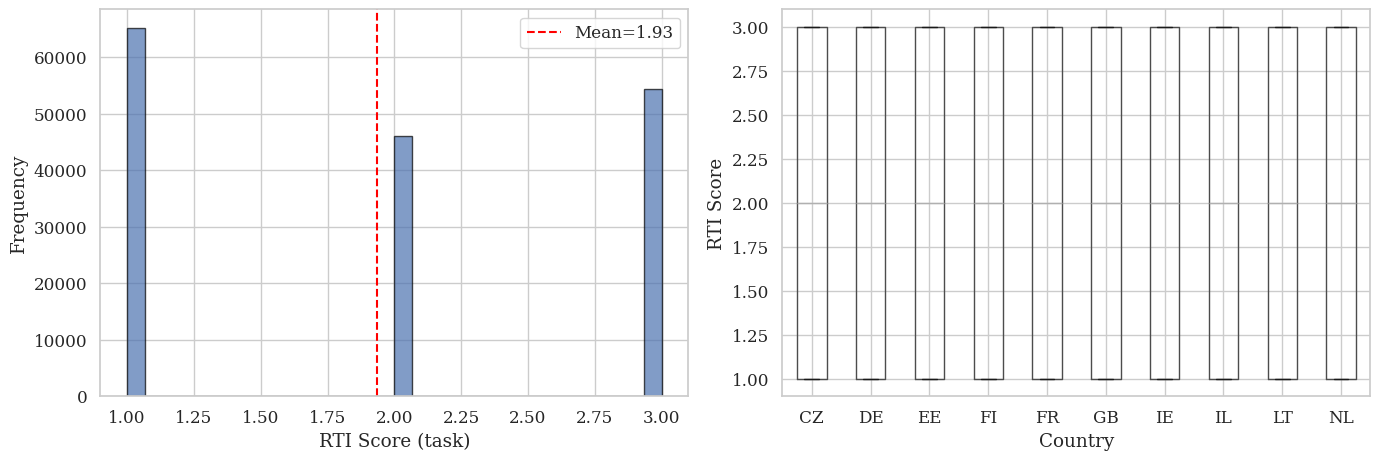

Saved: outputs/figures/rti_distribution.pdf


In [12]:
# --- RTI distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ess['task'].dropna().hist(bins=30, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('RTI Score (task)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(ess['task'].mean(), color='red', linestyle='--', label=f'Mean={ess["task"].mean():.2f}')
axes[0].legend()

# By country (top 10 by sample size)
top_countries = ess.groupby('cntry')['task'].count().nlargest(10).index
ess[ess['cntry'].isin(top_countries)].boxplot(column='task', by='cntry', ax=axes[1])
axes[1].set_xlabel('Country')
axes[1].set_ylabel('RTI Score')
plt.suptitle('')  # remove auto title
axes[1].set_title('')

plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'rti_distribution.pdf', bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/rti_distribution.pdf')

---
## 3. Construct Dependent Variables

### 3a. Anti-immigration attitudes (H1 DV)
- `imwbcnt`: Immigrants make country worse (0) to better (10) place to live
- `imueclt`: Cultural life undermined (0) to enriched (10)
- `imbgeco`: Bad (0) to good (10) for economy

**Note:** Higher values = MORE pro-immigration. For "anti-immigration" we may want to reverse-code, or just remember the direction.

### 3b. Redistribution support (H2 DV)
- `gincdif`: Government should reduce income differences (1=agree strongly … 5=disagree strongly)

**Note:** LOWER values = MORE support for redistribution. Will reverse-code for interpretability.

### 3c. Deservingness (H3 mediator — waves 4 & 8 only)
- `sbstrec`: Social benefits/services make people lazy (1=agree strongly … 5=disagree strongly)
- `sbprvpv`: Social benefits/services prevent widespread poverty
- `sbbsntx`: Social benefits/services cost businesses too much in taxes
- `uentrjb`: Unemployed should have to take any job or lose benefits

In [13]:
# --- 3a. Anti-immigration index ---
# Clean: ESS uses values like 77, 88, 99 for refusal/don't know/no answer
immig_vars = ['imwbcnt', 'imueclt', 'imbgeco']

for v in immig_vars:
    if v in ess.columns:
        ess[v] = pd.to_numeric(ess[v], errors='coerce')
        # ESS codes: valid range 0-10; anything >10 is missing
        ess.loc[ess[v] > 10, v] = np.nan
        ess.loc[ess[v] < 0, v] = np.nan

# Check availability
for v in immig_vars:
    if v in ess.columns:
        valid = ess[v].notna().sum()
        print(f'{v}: {valid:,} valid ({ess[v].notna().mean():.1%}), mean={ess[v].mean():.2f}, sd={ess[v].std():.2f}')

# Construct anti-immigration index (REVERSE-coded: higher = more anti-immigration)
# Original: 0=worse, 10=better. Reversed: 0=better, 10=worse.
for v in immig_vars:
    if v in ess.columns:
        ess[f'{v}_rev'] = 10 - ess[v]

rev_vars = [f'{v}_rev' for v in immig_vars if v in ess.columns]
ess['anti_immig_index'] = ess[rev_vars].mean(axis=1, skipna=True)
# Only valid if at least 2 of 3 items are non-missing
ess.loc[ess[rev_vars].notna().sum(axis=1) < 2, 'anti_immig_index'] = np.nan

print(f'\nAnti-immigration index: {ess["anti_immig_index"].notna().sum():,} valid')
print(f'  Mean={ess["anti_immig_index"].mean():.2f}, SD={ess["anti_immig_index"].std():.2f}')
print(f'  Range: [{ess["anti_immig_index"].min():.1f}, {ess["anti_immig_index"].max():.1f}]')
print('  (Higher = more anti-immigration)')

imwbcnt: 180,448 valid (95.6%), mean=4.98, sd=2.39
imueclt: 181,279 valid (96.0%), mean=5.48, sd=2.61
imbgeco: 180,833 valid (95.8%), mean=5.00, sd=2.52

Anti-immigration index: 183,035 valid
  Mean=4.85, SD=2.23
  Range: [0.0, 10.0]
  (Higher = more anti-immigration)


In [14]:
# --- Cronbach's alpha for the anti-immigration index ---
def cronbach_alpha(df):
    """Compute Cronbach's alpha for a set of items."""
    df_clean = df.dropna()
    k = df_clean.shape[1]
    if k < 2 or len(df_clean) < 10:
        return np.nan
    item_vars = df_clean.var(axis=0, ddof=1)
    total_var = df_clean.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

alpha = cronbach_alpha(ess[rev_vars])
print(f'Cronbach\'s alpha for anti-immigration index: {alpha:.3f}')
if alpha >= 0.7:
    print('  ✓ Acceptable internal consistency.')
else:
    print('  ⚠️ Below 0.7 threshold — consider using individual items instead of index.')

Cronbach's alpha for anti-immigration index: 0.864
  ✓ Acceptable internal consistency.


In [15]:
# --- 3b. Redistribution support ---
ess['gincdif'] = pd.to_numeric(ess['gincdif'], errors='coerce')
ess.loc[(ess['gincdif'] > 5) | (ess['gincdif'] < 1), 'gincdif'] = np.nan

# Reverse code: original 1=agree strongly (pro-redist), 5=disagree strongly
# Reversed: 1=disagree, 5=agree strongly → higher = more support for redistribution
ess['redist_support'] = 6 - ess['gincdif']

print(f'Redistribution support (reversed gincdif):')
print(f'  Valid: {ess["redist_support"].notna().sum():,} ({ess["redist_support"].notna().mean():.1%})')
print(f'  Mean={ess["redist_support"].mean():.2f}, SD={ess["redist_support"].std():.2f}')
print(f'  (Higher = more pro-redistribution)')

Redistribution support (reversed gincdif):
  Valid: 185,351 (98.2%)
  Mean=3.92, SD=1.01
  (Higher = more pro-redistribution)


In [16]:
# --- 3c. Deservingness items (H3 mediator) ---
# Only available in waves 4 and 8. Wave 8 is in our primary sample (waves 6-9).
deserv_vars = ['sbstrec', 'sbprvpv', 'sbbsntx', 'uentrjb']
present = [v for v in deserv_vars if v in ess.columns]

if present:
    for v in present:
        ess[v] = pd.to_numeric(ess[v], errors='coerce')
        ess.loc[(ess[v] > 5) | (ess[v] < 1), v] = np.nan
    
    # Report availability by wave
    print('Deservingness items availability by wave:')
    for v in present:
        by_wave = ess.groupby('essround')[v].apply(lambda x: x.notna().sum())
        print(f'  {v}: {dict(by_wave)}')
    
    # Construct strict deservingness index from wave 8
    # sbstrec: benefits make people lazy (1=agree strongly → narrow deservingness)
    # sbbsntx: benefits cost businesses too much
    # uentrjb: unemployed should take any job offered
    # These measure NARROW/PUNITIVE welfare attitudes — higher original = more lenient
    # Reverse so higher = more punitive/narrow
    w8_mask = ess['essround'] == 8
    if w8_mask.sum() > 0:
        for v in ['sbstrec', 'sbbsntx', 'uentrjb']:
            if v in ess.columns:
                ess[f'{v}_pun'] = 6 - ess[v]  # reverse: higher = more punitive
        
        pun_vars = [f'{v}_pun' for v in ['sbstrec', 'sbbsntx', 'uentrjb'] if f'{v}_pun' in ess.columns]
        if pun_vars:
            ess['narrow_deserving'] = ess[pun_vars].mean(axis=1, skipna=True)
            ess.loc[ess[pun_vars].notna().sum(axis=1) < 2, 'narrow_deserving'] = np.nan
            n_valid = ess.loc[w8_mask, 'narrow_deserving'].notna().sum()
            print(f'\nNarrow deservingness index (wave 8 only): {n_valid:,} valid')
            print(f'  (Higher = more punitive/narrow welfare attitudes)')
else:
    print('⚠️ No deservingness items found in primary sample. H3 mediation limited.')
    print('  sbstrec/sbprvpv/sbbsntx/uentrjb only in ESS waves 4 and 8.')

Deservingness items availability by wave:
  sbstrec: {6: np.int64(0), 7: np.int64(0), 8: np.int64(42224), 9: np.int64(0)}
  sbprvpv: {6: np.int64(0), 7: np.int64(0), 8: np.int64(43047), 9: np.int64(0)}
  sbbsntx: {6: np.int64(0), 7: np.int64(0), 8: np.int64(41063), 9: np.int64(0)}
  uentrjb: {6: np.int64(0), 7: np.int64(0), 8: np.int64(43313), 9: np.int64(0)}

Narrow deservingness index (wave 8 only): 42,699 valid
  (Higher = more punitive/narrow welfare attitudes)


In [17]:
# --- 3d. Radical right party vote ---
# Load populist crosswalk (SEMICOLON-delimited per MEMORY.md)
crosswalk = pd.read_csv(CROSSWALK_FILE, sep=';', encoding='latin-1')
print(f'Populist crosswalk: {crosswalk.shape[0]} rows, {crosswalk.shape[1]} columns')
print(f'Columns: {list(crosswalk.columns)}')
display(crosswalk.head(10))

Populist crosswalk: 3469 rows, 7 columns
Columns: ['cntry', 'essround', 'variable', 'ess_id', 'party', 'partyfacts_id', 'partyfacts_name']


,cntry,essround,variable,ess_id,party,partyfacts_id,partyfacts_name
0,AL,6,prtvtal,1,Partia Socialiste e Shqipërisë (PS),1729.0,PSS
1,AL,6,prtvtal,2,Partia Demokratike e Shqipërisë (PD),7013.0,PDS
2,AL,6,prtvtal,3,Lëvizja Socialiste për Integrim (LSI),2297.0,LSI
3,AL,6,prtvtal,4,Partia Republikane e Shqipërisë (PR),819.0,PRS
4,AL,6,prtvtal,5,Partia Socialdemokrate e Shqipërisë (PSD),838.0,PSD
5,AL,6,prtvtal,6,Partia Drejtësi,-9999.0,No ID
6,AL,6,prtvtal,7,Partia Bashkimi për të Drejtat e Njeriut (PBDNJ),1636.0,PBDN
7,AL,6,prtvtal,8,Other,-8888.0,Other
8,AL,6,prtvtal,66,Not applicable,NaN,NaN
9,AL,6,prtvtal,77,Refusal,NaN,NaN


In [18]:
# --- Construct radical right vote indicator ---
# The crosswalk maps ESS party codes to partyfacts IDs.
# We need to identify which parties are radical right / populist.
# Strategy: use the crosswalk to get party IDs, then check what classification exists.

# First, let's see what the crosswalk contains
print('Crosswalk columns:', list(crosswalk.columns))
print(f'Countries: {sorted(crosswalk["cntry"].unique())}')
print(f'Rounds: {sorted(crosswalk["essround"].unique())}')

# Check if there's a populism/radical right flag in the crosswalk
for col in crosswalk.columns:
    if any(term in col.lower() for term in ['popul', 'radical', 'right', 'type', 'family', 'class']):
        print(f'\nPotential classification column: {col}')
        print(crosswalk[col].value_counts().head(10))

Crosswalk columns: ['cntry', 'essround', 'variable', 'ess_id', 'party', 'partyfacts_id', 'partyfacts_name']
Countries: ['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LU', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'RU', 'SE', 'SI', 'SK', 'TR', 'UA', 'XK']
Rounds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [19]:
# --- Reshape ESS party vote into long format for merge ---
# ESS has country-specific prtvt columns. We need to:
# 1. For each respondent, find which prtvt column applies to their country
# 2. Get their party code
# 3. Merge with crosswalk

# Get all prtvt columns
prtvt_cols = [c for c in ess.columns if c.startswith('prtvt')]
print(f'Party vote columns in data: {len(prtvt_cols)}')

# For each respondent, extract their party vote code
# The crosswalk 'variable' column tells us which prtvt column to use per country × round
ess['party_code'] = np.nan
ess['prtvt_var'] = ''

for _, row in crosswalk[['cntry', 'essround', 'variable']].drop_duplicates().iterrows():
    var_name = row['variable']
    if var_name in ess.columns:
        mask = (ess['cntry'] == row['cntry']) & (ess['essround'] == row['essround'])
        vals = pd.to_numeric(ess.loc[mask, var_name], errors='coerce')
        ess.loc[mask, 'party_code'] = vals
        ess.loc[mask, 'prtvt_var'] = var_name

has_vote = ess['party_code'].notna()
print(f'Respondents with party vote code: {has_vote.sum():,} ({has_vote.mean():.1%})')

Party vote columns in data: 69
Respondents with party vote code: 166,061 (88.0%)


### ⚠️ NOTE on radical right classification

The Langenkamp crosswalk maps ESS party codes to `partyfacts_id` but does **not** contain a built-in radical right / populist flag. To create a binary `radical_right_vote` indicator, we need one of:

1. **Global Party Survey (GPS)** populism scores — available in `data/raw/baccini_2024/Raw Data/Global_Party_Survey/`
2. **Chapel Hill Expert Survey (CHES)** party family codes
3. **Manual classification** using known party lists (e.g., Mudde 2007, Norris & Inglehart 2019)

**Decision needed from Ben:** Which classification to use? For now, I'll note the merge infrastructure is in place and write placeholder code.

In [20]:
# --- Check if GPS data is available for party classification ---
GPS_FILE = ROOT / 'data' / 'raw' / 'baccini_2024' / 'Replication V3' / 'Data' / 'Raw Data' / 'Global_Party_Survey_by_Party_Stata_V1_10_Feb_2020.dta'

if GPS_FILE.exists():
    gps, gps_meta = pyreadstat.read_dta(str(GPS_FILE))
    print(f'GPS file found: {GPS_FILE.name}')
    print(f'  Shape: {gps.shape[0]} parties × {gps.shape[1]} variables')
    print(f'  Columns: {list(gps.columns)[:20]}...')
    # Look for populism score
    pop_cols = [c for c in gps.columns if 'popul' in c.lower()]
    print(f'  Populism-related columns: {pop_cols}')
    if pop_cols:
        for col in pop_cols:
            print(f'    {col}: mean={gps[col].mean():.2f}, sd={gps[col].std():.2f}, range=[{gps[col].min():.1f}, {gps[col].max():.1f}]')
    print(f'\n  ⚠️ GPS provides populism scores per party. To classify radical right voters,')
    print(f'  we need to link GPS party IDs → Langenkamp crosswalk partyfacts IDs → ESS party codes.')
    print(f'  This merge chain is non-trivial. Consider using CHES party family codes as alternative.')
else:
    print(f'GPS file not found at: {GPS_FILE}')

GPS file found: Global_Party_Survey_by_Party_Stata_V1_10_Feb_2020.dta
  Shape: 2670 parties × 154 variables
  Columns: ['ID_GPS', 'ISO', 'Country', 'Partyname', 'Partyabb', 'CPARTY', 'CPARTYABB', 'Region', 'Experts', 'Min_Experts', 'TYPES', 'Type_Values', 'Type_Populism', 'Type_Populist_Values', 'Type_Partysize_vote', 'Type_Partysize_seat', 'CORE_GPS_ITEMS', 'V1', 'V2', 'V3']...
  Populism-related columns: ['Type_Populism', 'Type_Populist_Values']
    Type_Populism: mean=2.76, sd=0.99, range=[1.0, 4.0]
    Type_Populist_Values: mean=2.48, sd=1.47, range=[0.0, 4.0]

  ⚠️ GPS provides populism scores per party. To classify radical right voters,
  we need to link GPS party IDs → Langenkamp crosswalk partyfacts IDs → ESS party codes.
  This merge chain is non-trivial. Consider using CHES party family codes as alternative.


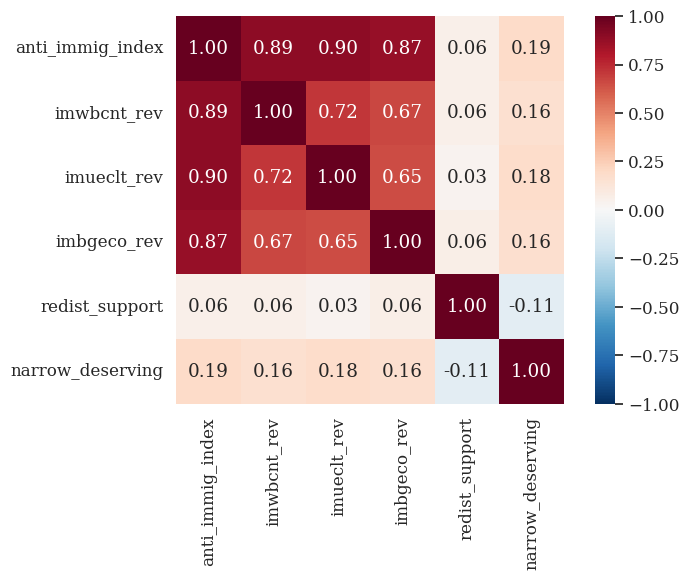

Key correlations:
  Anti-immig index ↔ Redist support: 0.057
  (Negative = anti-immigration people are LESS pro-redistribution)
  (Weak/zero = measuring distinct constructs, as desired)


In [21]:
# --- DV correlation matrix ---
dv_cols = ['anti_immig_index', 'imwbcnt_rev', 'imueclt_rev', 'imbgeco_rev',
           'redist_support']
if 'narrow_deserving' in ess.columns:
    dv_cols.append('narrow_deserving')
dv_cols_present = [c for c in dv_cols if c in ess.columns]

corr = ess[dv_cols_present].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'dv_correlation_matrix.pdf', bbox_inches='tight')
plt.show()

print('Key correlations:')
print(f'  Anti-immig index ↔ Redist support: {corr.loc["anti_immig_index", "redist_support"]:.3f}')
print('  (Negative = anti-immigration people are LESS pro-redistribution)')
print('  (Weak/zero = measuring distinct constructs, as desired)')

---
## 4. Search for Welfare Indicators in Existing Replication Data

**Goal:** Before downloading new data, check what country-level welfare indicators already exist in the repo.

**Key sources identified:**
1. **CPDS** (`baccini_2024/`): ALMP spending, social expenditure, EPL — 36 countries, 1960–2018
2. **SIWE** (`siwe_2017/`): Detailed ALMP/PLMP split, welfare type taxonomy — 29 countries, 1995–2014
3. **Gingrich RP_Context_Data**: ALMP per GDP, per person

In [22]:
# --- 4a. CPDS (Comparative Political Data Set) ---
cpds, cpds_meta = pyreadstat.read_dta(str(CPDS_FILE))
print(f'CPDS: {cpds.shape[0]} rows × {cpds.shape[1]} columns')
print(f'Years: {cpds["year"].min():.0f}–{cpds["year"].max():.0f}')
print(f'Countries: {cpds["country"].nunique()}')

# Find welfare-relevant columns
welfare_keywords = ['soc', 'almp', 'unemp', 'welfare', 'benefit', 'pension',
                    'health', 'family', 'housing', 'emprot', 'educ', 'train',
                    'incent', 'jobcrea', 'compen', 'oldage', 'disab']

welfare_cols = [c for c in cpds.columns
               if any(kw in c.lower() for kw in welfare_keywords)]

print(f'\nWelfare-relevant columns ({len(welfare_cols)}):')
for col in sorted(welfare_cols):
    n_valid = cpds[col].notna().sum()
    label = cpds_meta.column_names_to_labels.get(col, '')
    print(f'  {col}: {n_valid} valid obs — {label[:80]}')

CPDS: 1722 rows × 321 columns
Years: 1960–2018
Countries: 36

Welfare-relevant columns (58):
  almp_pmp: 866 valid obs — Active labour market programs expenditure, % of GDP (public/mandatory private)
  compen_pmp: 1027 valid obs — Unemployment compensation and severance pay (in cash), % of GDP (public/mandator
  disabled_pmp: 865 valid obs — Supported employment and rehabilitation, % of GDP (public/mandatory private)
  educatt_minimal: 600 valid obs — Share of population attending no more than secondary education
  educatt_minimal_ipol: 624 valid obs — Linear interpolation of share of population attending no more than secondary edu
  educatt_tertiary: 608 valid obs — Share of population attending tertiary education
  educatt_tertiary_ipol: 628 valid obs — Linear interpolation of share of population attending tertiary education
  educexp_gov: 1086 valid obs — General government expenditure on education (current, capital and transfers) as
  educexp_gov_ipol: 1282 valid obs — Linear inter

In [23]:
# --- Key CPDS indicators for our analysis ---
# These are the most relevant for the sorting mechanism theory:
cpds_key = ['country', 'year',
            'almp_pmp',      # ALMP spending (% GDP) — active labour market
            'unemp_pmp',     # Unemployment cash benefits (% GDP) — passive
            'socexp_t_pmp',  # Total social expenditure (% GDP)
            'emprot_reg',    # Employment protection (regular contracts)
            'emprot_temp',   # Employment protection (temporary contracts)
            'training_pmp',  # Training spending (ALMP subcomponent)
            'incent_pmp',    # Employment incentives (ALMP subcomponent)
            'jobcrea_pmp',   # Direct job creation (ALMP subcomponent)
            ]

cpds_key_present = [c for c in cpds_key if c in cpds.columns]
cpds_welfare = cpds[cpds_key_present].copy()

# Filter to ESS-relevant years (2002-2018 for waves 1-9)
cpds_ess = cpds_welfare[(cpds_welfare['year'] >= 2002) & (cpds_welfare['year'] <= 2019)].copy()

print(f'CPDS welfare indicators for ESS period (2002-2019):')
print(f'  Rows: {len(cpds_ess)}')
print(f'  Countries: {cpds_ess["country"].nunique()}')
print(f'\nMissingness:')
for col in cpds_key_present[2:]:
    pct = cpds_ess[col].notna().mean()
    print(f'  {col}: {pct:.1%} non-missing')

# Construct key ratios
# 1. Active/Passive ratio: ALMP / (ALMP + unemployment benefits)
cpds_ess['active_passive_ratio'] = cpds_ess['almp_pmp'] / (cpds_ess['almp_pmp'] + cpds_ess['unemp_pmp'])

# 2. Training share of ALMP (enabling vs. punitive)
if 'training_pmp' in cpds_ess.columns:
    cpds_ess['training_share'] = cpds_ess['training_pmp'] / cpds_ess['almp_pmp']

# 3. Incentive/sanctions share (punitive activation)
if 'incent_pmp' in cpds_ess.columns:
    cpds_ess['incentive_share'] = cpds_ess['incent_pmp'] / cpds_ess['almp_pmp']

print(f'\nConstructed ratios:')
for ratio in ['active_passive_ratio', 'training_share', 'incentive_share']:
    if ratio in cpds_ess.columns:
        print(f'  {ratio}: mean={cpds_ess[ratio].mean():.3f}, sd={cpds_ess[ratio].std():.3f}')

CPDS welfare indicators for ESS period (2002-2019):
  Rows: 612
  Countries: 36

Missingness:
  almp_pmp: 67.2% non-missing
  unemp_pmp: 83.7% non-missing
  socexp_t_pmp: 97.1% non-missing
  emprot_reg: 78.8% non-missing
  emprot_temp: 78.8% non-missing
  training_pmp: 82.0% non-missing
  incent_pmp: 79.7% non-missing
  jobcrea_pmp: 77.5% non-missing

Constructed ratios:
  active_passive_ratio: mean=0.367, sd=0.138
  training_share: mean=0.262, sd=0.166
  incentive_share: mean=0.171, sd=0.145


In [24]:
# --- 4b. SIWE (Social Investment Welfare Expenditure) ---
siwe, siwe_meta = pyreadstat.read_dta(str(SIWE_FILE))
print(f'SIWE: {siwe.shape[0]} rows × {siwe.shape[1]} columns')
print(f'\nAll columns:')
for col in siwe.columns:
    label = siwe_meta.column_names_to_labels.get(col, '')
    n_valid = siwe[col].notna().sum()
    print(f'  {col}: {n_valid} valid — {label[:70]}')

SIWE: 580 rows × 64 columns

All columns:
  time: 580 valid — time
  geo: 580 valid — Country
  geo_numeric: 580 valid — Country number
  ppp_nac: 580 valid — PPP conversion factor (from NAC, 2005 constant prices)
  gdp: 580 valid — GDP (ESA2010)
  cpi_esa2010: 574 valid — Price deflator (ESA2010, base 2005)
  cpi_esa95: 540 valid — Price deflator (ESA95, base 2005)
  gdp_pc_esa2010: 577 valid — GDP per capita (ESA2010)
  gdp_pc_esa95: 544 valid — GDP per capita (ESA95)
  ert_eur: 580 valid — Exchange rate (NAC to EUR)
  unempl: 545 valid — Unemployed persons (thousands)
  pop_total: 580 valid — Total population
  pop_lt5: 580 valid — Population 0-4
  pop_5_19: 580 valid — Population 5-19
  pop_65: 580 valid — Population 65+
  health: 543 valid — Health & Sickness
  oldage_cash: 543 valid — Old age - cash benefits
  oldage_inkind: 543 valid — Old age - benefits in kind
  survivors: 543 valid — Survivors benefits
  disability_cash: 543 valid — Disability - cash benefits
  disability_eci

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# --- 4c. Gingrich context data ---
gingrich_ctx, gingrich_meta = pyreadstat.read_dta(str(GINGRICH_CTX))
print(f'Gingrich RP_Context_Data: {gingrich_ctx.shape[0]} rows × {gingrich_ctx.shape[1]} columns')
print(f'\nColumns:')
for col in gingrich_ctx.columns:
    label = gingrich_meta.column_names_to_labels.get(col, '')
    print(f'  {col} — {label[:70]}')

### Welfare indicator assessment

**What we have:**
- ALMP spending (% GDP): CPDS `almp_pmp` — good proxy for **activation orientation**
- Unemployment benefits (% GDP): CPDS `unemp_pmp` — proxy for **passive compensation**
- Active/passive ratio: constructed — higher = more activation-oriented
- Training share of ALMP: constructed — higher = more **enabling** (vs. punitive) activation
- Total social expenditure: CPDS `socexp_t_pmp` — overall generosity
- SIWE: detailed ALMP/PLMP breakdown with social investment composite indices

**What we're missing:**
- **Explicit conditionality index** (Knotz 2018) — not in repo, would need CWED or separate download
- **Net replacement rates** — not directly in CPDS, would need OECD Benefits & Wages database
- **Universalism index** (Scruggs CWED) — not in repo

**Can we proceed?** Yes — the CPDS active/passive ratio and training share are reasonable proxies for the conditionality/universalism distinction. The training share of ALMP captures the difference between enabling activation (upskilling) and punitive activation (workfare/incentive reinforcement). This maps onto the theoretical distinction between dignity-preserving and stigmatising welfare design.

**For the seminar paper, this is sufficient. For the dissertation, we should obtain CWED and OECD Benefits & Wages data for more precise measurement.**

---
## 5. Construct Controls & Merge Welfare Indicators

In [ ]:
# --- Clean control variables ---

# Age
ess['agea'] = pd.to_numeric(ess['agea'], errors='coerce')
ess.loc[(ess['agea'] > 110) | (ess['agea'] < 15), 'agea'] = np.nan
ess['age_sq'] = ess['agea'] ** 2

# Gender (1=male, 2=female in ESS)
ess['gndr'] = pd.to_numeric(ess['gndr'], errors='coerce')
ess['female'] = (ess['gndr'] == 2).astype(float)
ess.loc[ess['gndr'].isna() | (ess['gndr'] > 2), 'female'] = np.nan

# Education (ISCED)
ess['eisced'] = pd.to_numeric(ess['eisced'], errors='coerce')
ess.loc[(ess['eisced'] > 7) | (ess['eisced'] < 1), 'eisced'] = np.nan

# Education years
ess['eduyrs'] = pd.to_numeric(ess['eduyrs'], errors='coerce')
ess.loc[(ess['eduyrs'] > 40) | (ess['eduyrs'] < 0), 'eduyrs'] = np.nan

# Income (hinctnta: household income decile, waves 4+)
ess['hinctnta'] = pd.to_numeric(ess['hinctnta'], errors='coerce')
ess.loc[(ess['hinctnta'] > 10) | (ess['hinctnta'] < 1), 'hinctnta'] = np.nan

# Domicile (1=big city ... 5=countryside)
ess['domicil'] = pd.to_numeric(ess['domicil'], errors='coerce')
ess.loc[(ess['domicil'] > 5) | (ess['domicil'] < 1), 'domicil'] = np.nan
ess['urban'] = (ess['domicil'] <= 2).astype(float)  # big city or suburbs
ess.loc[ess['domicil'].isna(), 'urban'] = np.nan

# Left-right scale
ess['lrscale'] = pd.to_numeric(ess['lrscale'], errors='coerce')
ess.loc[(ess['lrscale'] > 10) | (ess['lrscale'] < 0), 'lrscale'] = np.nan

# Subjective insecurity
if 'emplno' in ess.columns:
    ess['emplno'] = pd.to_numeric(ess['emplno'], errors='coerce')
    ess.loc[(ess['emplno'] > 4) | (ess['emplno'] < 1), 'emplno'] = np.nan

# Report missingness
control_report = ['agea', 'female', 'eisced', 'eduyrs', 'hinctnta',
                  'urban', 'lrscale', 'emplno']
print('Control variable missingness:')
for v in control_report:
    if v in ess.columns:
        pct = ess[v].notna().mean()
        print(f'  {v}: {pct:.1%} non-missing')

In [ ]:
# --- Merge welfare indicators onto ESS ---
# Need to map ESS round → fieldwork year for CPDS merge
# ESS rounds and approximate fieldwork years:
round_to_year = {
    1: 2002, 2: 2004, 3: 2006, 4: 2008, 5: 2010,
    6: 2012, 7: 2014, 8: 2016, 9: 2018
}
ess['fieldwork_year'] = ess['essround'].map(round_to_year)

# CPDS uses country names; ESS uses ISO-2 codes. Build mapping.
# Check what CPDS uses
print('CPDS country identifiers:')
print(sorted(cpds['country'].unique())[:20])

In [ ]:
# --- Map CPDS country names to ESS ISO-2 codes ---
# CPDS uses full country names; ESS uses 2-letter codes
cpds_to_ess = {
    'Australia': 'AU', 'Austria': 'AT', 'Belgium': 'BE', 'Bulgaria': 'BG',
    'Canada': 'CA', 'Croatia': 'HR', 'Cyprus': 'CY', 'Czech Republic': 'CZ',
    'Denmark': 'DK', 'Estonia': 'EE', 'Finland': 'FI', 'France': 'FR',
    'Germany': 'DE', 'Greece': 'GR', 'Hungary': 'HU', 'Iceland': 'IS',
    'Ireland': 'IE', 'Israel': 'IL', 'Italy': 'IT', 'Japan': 'JP',
    'Latvia': 'LV', 'Lithuania': 'LT', 'Luxembourg': 'LU',
    'Netherlands': 'NL', 'New Zealand': 'NZ', 'Norway': 'NO',
    'Poland': 'PL', 'Portugal': 'PT', 'Romania': 'RO',
    'Slovakia': 'SK', 'Slovenia': 'SI', 'Spain': 'ES',
    'Sweden': 'SE', 'Switzerland': 'CH', 'Turkey': 'TR',
    'United Kingdom': 'GB', 'United States': 'US'
}

cpds_ess['cntry'] = cpds_ess['country'].map(cpds_to_ess)

# Select welfare indicators for merge
welfare_merge_cols = ['cntry', 'year', 'almp_pmp', 'unemp_pmp', 'socexp_t_pmp',
                      'active_passive_ratio', 'training_share', 'incentive_share']
welfare_merge_cols = [c for c in welfare_merge_cols if c in cpds_ess.columns]
welfare_for_merge = cpds_ess[welfare_merge_cols].dropna(subset=['cntry']).copy()

# Merge on country × fieldwork year
n_before = len(ess)
ess = ess.merge(
    welfare_for_merge.rename(columns={'year': 'fieldwork_year'}),
    on=['cntry', 'fieldwork_year'],
    how='left'
)
assert len(ess) == n_before, f'Row inflation in welfare merge: {n_before} → {len(ess)}'

welfare_match = ess['almp_pmp'].notna().mean()
print(f'Welfare indicator merge rate: {welfare_match:.1%}')
if welfare_match < 0.5:
    print('⚠️ Low match rate — check country name mapping')
    unmatched = ess.loc[ess['almp_pmp'].isna(), 'cntry'].unique()
    print(f'  Unmatched ESS countries: {sorted(unmatched)}')
else:
    print('✓ Good match rate.')

In [ ]:
# --- Welfare regime classification ---
# Esping-Andersen (1990) + Ferrera (1996) for Southern Europe
welfare_regimes = {
    'Nordic': ['DK', 'SE', 'NO', 'FI', 'IS'],
    'Continental': ['DE', 'FR', 'AT', 'BE', 'NL', 'CH', 'LU'],
    'Liberal': ['GB', 'IE'],
    'Southern': ['ES', 'IT', 'PT', 'GR', 'CY'],
    'Eastern': ['PL', 'CZ', 'HU', 'SK', 'SI', 'EE', 'LT', 'LV',
                       'BG', 'RO', 'HR']
}

regime_map = {}
for regime, countries in welfare_regimes.items():
    for c in countries:
        regime_map[c] = regime

ess['welfare_regime'] = ess['cntry'].map(regime_map)
unclassified = ess.loc[ess['welfare_regime'].isna(), 'cntry'].unique()
if len(unclassified) > 0:
    print(f'Countries without regime classification: {sorted(unclassified)}')
    # Assign remaining to 'Other'
    ess.loc[ess['welfare_regime'].isna(), 'welfare_regime'] = 'Other'

print('\nObservations by welfare regime:')
print(ess['welfare_regime'].value_counts().sort_index())

# Create country × wave identifier for multilevel models
ess['cntry_wave'] = ess['cntry'] + '_' + ess['essround'].astype(str)

---
## 6. Descriptive Analysis

**The key question:** Is the sorting pattern visible in the raw data? Do high-RTI workers in different welfare regimes show different political attitudes?

In [ ]:
# --- 6a. Summary statistics by welfare regime ---
analysis_vars = ['task', 'anti_immig_index', 'redist_support', 'agea',
                 'female', 'eduyrs', 'hinctnta', 'lrscale']
analysis_vars = [v for v in analysis_vars if v in ess.columns]

summary_by_regime = (ess
    .groupby('welfare_regime')[analysis_vars]
    .agg(['mean', 'std', 'count'])
)

# Flatten and display
print('Summary statistics by welfare regime type:')
print('=' * 80)
for var in ['task', 'anti_immig_index', 'redist_support']:
    if var in analysis_vars:
        print(f'\n--- {var} ---')
        sub = summary_by_regime[var].round(3)
        display(sub)

In [ ]:
# --- 6b. THE KEY PLOT: RTI vs. anti-immigration, by welfare regime ---
# This is the visual test of H1: is the slope steeper in conditional/liberal regimes?

# Filter to main 4 regime types and observations with both RTI and DV
plot_regimes = ['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern']
plot_df = ess[
    ess['welfare_regime'].isin(plot_regimes) &
    ess['task'].notna() &
    ess['anti_immig_index'].notna()
].copy()

print(f'Observations for key plot: {len(plot_df):,}')
print(f'By regime: {dict(plot_df["welfare_regime"].value_counts())}')

# Binned scatter: divide RTI into deciles within each regime, plot mean DV
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
regime_order = ['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern']

axes_list = axes.flatten().tolist()
for idx_plot, regime in enumerate(regime_order):
    ax = axes_list[idx_plot]
    rdf = plot_df[plot_df['welfare_regime'] == regime].copy()
    if len(rdf) < 100:
        ax.set_title(f'{regime} (N={len(rdf)} — too few)')
        continue
    
    # Create RTI bins (ventiles for smoother curve)
    rdf['rti_bin'] = pd.qcut(rdf['task'], q=20, duplicates='drop')
    binned = rdf.groupby('rti_bin', observed=True).agg(
        rti_mean=('task', 'mean'),
        dv_mean=('anti_immig_index', 'mean'),
        dv_se=('anti_immig_index', lambda x: x.std() / np.sqrt(len(x))),
        n=('anti_immig_index', 'count')
    ).reset_index()
    
    # Plot binned scatter with error bars
    ax.errorbar(binned['rti_mean'], binned['dv_mean'],
                yerr=1.96 * binned['dv_se'], fmt='o', markersize=5,
                capsize=2, alpha=0.8)
    
    # Add linear fit
    z = np.polyfit(rdf['task'].dropna(), rdf.loc[rdf['task'].notna(), 'anti_immig_index'], 1)
    x_range = np.linspace(rdf['task'].min(), rdf['task'].max(), 100)
    ax.plot(x_range, np.polyval(z, x_range), 'r--', alpha=0.7,
            label=f'slope={z[0]:.3f}')
    
    ax.set_xlabel('RTI Score (automation exposure)')
    ax.set_ylabel('Anti-immigration index (0-10)')
    ax.set_title(f'{regime} (N={len(rdf):,})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'fig2_rti_vs_antiimmig_by_regime.pdf',
            bbox_inches='tight')
plt.show()

print('\nSlopes by regime (OLS, no controls):')
for regime in regime_order:
    rdf = plot_df[plot_df['welfare_regime'] == regime]
    valid = rdf[['task', 'anti_immig_index']].dropna()
    if len(valid) > 100:
        z = np.polyfit(valid['task'], valid['anti_immig_index'], 1)
        print(f'  {regime}: β = {z[0]:.4f} (N={len(valid):,})')

print('\nInterpretation guide:')
print('  If sorting mechanism is real: slopes should be steeper (more positive)')
print('  in Liberal/Southern (conditional) than in Nordic (universal).')
print('  ⚠️ These are raw associations without controls — interpret cautiously.')

In [ ]:
# --- 6c. RTI vs. redistribution support, by welfare regime ---
# H2: vulnerability should predict MORE solidaristic attitudes in universal regimes

plot_df2 = ess[
    ess['welfare_regime'].isin(plot_regimes) &
    ess['task'].notna() &
    ess['redist_support'].notna()
].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes_list = axes.flatten().tolist()
for idx_plot, regime in enumerate(regime_order):
    ax = axes_list[idx_plot]
    rdf = plot_df2[plot_df2['welfare_regime'] == regime].copy()
    if len(rdf) < 100:
        ax.set_title(f'{regime} (N={len(rdf)} — too few)')
        continue
    
    rdf['rti_bin'] = pd.qcut(rdf['task'], q=20, duplicates='drop')
    binned = rdf.groupby('rti_bin', observed=True).agg(
        rti_mean=('task', 'mean'),
        dv_mean=('redist_support', 'mean'),
        dv_se=('redist_support', lambda x: x.std() / np.sqrt(len(x))),
    ).reset_index()
    
    ax.errorbar(binned['rti_mean'], binned['dv_mean'],
                yerr=1.96 * binned['dv_se'], fmt='o', markersize=5,
                capsize=2, alpha=0.8, color='green')
    
    z = np.polyfit(rdf['task'].dropna(), rdf.loc[rdf['task'].notna(), 'redist_support'], 1)
    x_range = np.linspace(rdf['task'].min(), rdf['task'].max(), 100)
    ax.plot(x_range, np.polyval(z, x_range), 'r--', alpha=0.7,
            label=f'slope={z[0]:.3f}')
    
    ax.set_xlabel('RTI Score (automation exposure)')
    ax.set_ylabel('Redistribution support (1-5)')
    ax.set_title(f'{regime} (N={len(rdf):,})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'fig4_rti_vs_redistribution_by_regime.pdf',
            bbox_inches='tight')
plt.show()

print('\nSlopes by regime (OLS, no controls):')
for regime in regime_order:
    rdf = plot_df2[plot_df2['welfare_regime'] == regime]
    valid = rdf[['task', 'redist_support']].dropna()
    if len(valid) > 100:
        z = np.polyfit(valid['task'], valid['redist_support'], 1)
        print(f'  {regime}: β = {z[0]:.4f} (N={len(valid):,})')

print('\nInterpretation guide:')
print('  If sorting mechanism is real: high-RTI workers in Nordic regimes should')
print('  show MORE redistribution support (positive slope), while in Liberal/Southern')
print('  regimes the slope should be flat or negative.')

In [ ]:
# --- 6d. Welfare indicators vs. RTI-attitude slopes across countries ---
# For each country-wave, compute the raw slope of RTI → anti-immigration
# Then plot this slope against the country's ALMP or activation ratio

from scipy import stats

slopes = []
for (cntry, wave), group in ess.groupby(['cntry', 'essround']):
    valid = group[['task', 'anti_immig_index']].dropna()
    if len(valid) >= 50:  # need minimum sample
        slope, _, r, p, se = stats.linregress(valid['task'], valid['anti_immig_index'])
        welfare_vals = group[['almp_pmp', 'active_passive_ratio', 'socexp_t_pmp']].iloc[0]
        slopes.append({
            'cntry': cntry, 'essround': wave,
            'rti_slope': slope, 'rti_slope_se': se, 'rti_r': r, 'rti_p': p,
            'n': len(valid),
            'regime': group['welfare_regime'].iloc[0],
            **welfare_vals.to_dict()
        })

slopes_df = pd.DataFrame(slopes)
print(f'Country-wave slope estimates: {len(slopes_df)}')

# Plot: ALMP spending vs. RTI→anti-immigration slope
plot_slopes = slopes_df[slopes_df['almp_pmp'].notna()].copy()

if len(plot_slopes) > 5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ALMP spending
    regime_colors = {'Nordic': 'blue', 'Continental': 'orange', 'Liberal': 'red',
                     'Southern': 'green', 'Post-socialist': 'purple', 'Other': 'gray'}
    
    for regime in plot_slopes['regime'].unique():
        rdf = plot_slopes[plot_slopes['regime'] == regime]
        axes[0].scatter(rdf['almp_pmp'], rdf['rti_slope'],
                       c=regime_colors.get(regime, 'gray'), label=regime, alpha=0.7, s=40)
    axes[0].axhline(0, color='black', linestyle=':', alpha=0.5)
    axes[0].set_xlabel('ALMP spending (% GDP)')
    axes[0].set_ylabel('RTI → Anti-immigration slope')
    axes[0].legend(fontsize=8)
    
    # Active/passive ratio
    plot_slopes2 = slopes_df[slopes_df['active_passive_ratio'].notna()]
    for regime in plot_slopes2['regime'].unique():
        rdf = plot_slopes2[plot_slopes2['regime'] == regime]
        axes[1].scatter(rdf['active_passive_ratio'], rdf['rti_slope'],
                       c=regime_colors.get(regime, 'gray'), label=regime, alpha=0.7, s=40)
    axes[1].axhline(0, color='black', linestyle=':', alpha=0.5)
    axes[1].set_xlabel('Active/Passive spending ratio')
    axes[1].set_ylabel('RTI → Anti-immigration slope')
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(ROOT / 'outputs' / 'figures' / 'welfare_vs_rti_slopes.pdf', bbox_inches='tight')
    plt.show()
    
    # Correlation
    r1, p1 = stats.pearsonr(plot_slopes['almp_pmp'], plot_slopes['rti_slope'])
    print(f'\nCorrelation: ALMP spending ↔ RTI-attitude slope: r={r1:.3f}, p={p1:.3f}')
    if 'active_passive_ratio' in plot_slopes2.columns:
        valid2 = plot_slopes2[['active_passive_ratio', 'rti_slope']].dropna()
        r2, p2 = stats.pearsonr(valid2['active_passive_ratio'], valid2['rti_slope'])
        print(f'Correlation: Active/passive ratio ↔ RTI-attitude slope: r={r2:.3f}, p={p2:.3f}')
else:
    print('⚠️ Too few country-waves with both slopes and welfare indicators for scatter plot.')

---
## 7. Model Specifications

These are the model specifications for the main hypotheses. Written as executable code blocks — some may not run if welfare indicators are missing for certain countries, but the specification is complete.

### Key modelling decision (from MEMORY.md):
Country × wave FE absorb country-level time-invariant variables. The multilevel model with random intercepts is the correct specification for testing cross-level interactions. Country FE can be used in robustness but then welfare indicators enter only as interactions.

In [ ]:
# --- Prepare analysis sample ---
# Keep observations with: RTI score + at least one DV + controls
model_vars = ['task', 'anti_immig_index', 'redist_support',
              'agea', 'age_sq', 'female', 'eisced', 'hinctnta', 'urban',
              'cntry_wave', 'cntry', 'essround', 'welfare_regime']

# Welfare indicators (may be missing for some countries)
welfare_vars = ['almp_pmp', 'active_passive_ratio', 'socexp_t_pmp']
welfare_present = [v for v in welfare_vars if v in ess.columns]

# H1 analysis sample: RTI + anti-immig + core controls
h1_vars = ['task', 'anti_immig_index', 'agea', 'age_sq', 'female',
            'eisced', 'hinctnta', 'urban', 'cntry_wave', 'cntry', 'essround']
h1_sample = ess[h1_vars + welfare_present].dropna(subset=h1_vars)

# H2 analysis sample: RTI + redistribution + core controls
h2_vars = ['task', 'redist_support', 'agea', 'age_sq', 'female',
            'eisced', 'hinctnta', 'urban', 'cntry_wave', 'cntry', 'essround']
h2_sample = ess[h2_vars + welfare_present].dropna(subset=h2_vars)

print(f'H1 analysis sample (RTI + anti-immigration + controls): {len(h1_sample):,}')
print(f'  Countries: {h1_sample["cntry"].nunique()}')
print(f'  Country-waves: {h1_sample["cntry_wave"].nunique()}')
print(f'  With welfare indicators: {h1_sample[welfare_present[0]].notna().sum():,}' if welfare_present else '  No welfare indicators')
print(f'\nH2 analysis sample (RTI + redistribution + controls): {len(h2_sample):,}')
print(f'  Countries: {h2_sample["cntry"].nunique()}')

In [ ]:
# ============================================================
# MODEL 1 (H1): Anti-immigration = f(RTI × welfare indicator)
# ============================================================
# Multilevel model with country-wave random intercepts
#
# Y_ij = β₀ + β₁(RTI_i) + β₂(welfare_j) + β₃(RTI_i × welfare_j)
#        + γ(controls_i) + u_j + ε_ij
#
# β₃ is the key coefficient:
#   If welfare = ALMP spending: β₃ < 0 means more ALMP → weaker RTI→exclusion link
#   If welfare = active/passive ratio: same interpretation
#
# NOTE: If welfare indicators are missing for too many countries,
# the interaction cannot be estimated. In that case, we fall back to
# the regime-type interaction.

import statsmodels.formula.api as smf

# --- Model 1a: RTI × ALMP spending ---
h1a_sample = h1_sample.dropna(subset=['almp_pmp']).copy() if 'almp_pmp' in h1_sample.columns else pd.DataFrame()

if len(h1a_sample) > 1000 and h1a_sample['cntry'].nunique() >= 10:
    # Standardise continuous predictors for interpretable interaction
    for v in ['task', 'almp_pmp', 'agea', 'hinctnta']:
        h1a_sample[f'{v}_z'] = (h1a_sample[v] - h1a_sample[v].mean()) / h1a_sample[v].std()
    h1a_sample['age_sq_z'] = h1a_sample['agea_z'] ** 2
    
    m1a = smf.mixedlm(
        'anti_immig_index ~ task_z * almp_pmp_z + agea_z + age_sq_z + female + eisced + hinctnta_z + urban',
        data=h1a_sample,
        groups=h1a_sample['cntry_wave']
    ).fit(reml=True)
    
    print('='*60)
    print('MODEL 1a: Anti-immigration ~ RTI × ALMP spending')
    print('='*60)
    print(m1a.summary())
    print(f'\nKey coefficient (task_z:almp_pmp_z): {m1a.params.get("task_z:almp_pmp_z", "N/A")}')
    print('Interpretation: negative = more ALMP spending weakens the RTI→exclusion link')
else:
    print('⚠️ Cannot estimate Model 1a: insufficient observations with ALMP data')
    print(f'  N={len(h1a_sample)}, countries={h1a_sample["cntry"].nunique() if len(h1a_sample)>0 else 0}')
    print('  Need: N>1000, countries≥10')

In [ ]:
# --- Model 1b: RTI × welfare regime type ---
# This is a fallback/complement: uses categorical regime instead of continuous indicator
# Advantage: no missing welfare data. Disadvantage: less precise, more assumption-laden.

h1b_sample = h1_sample[h1_sample['welfare_regime'].isin(['Nordic', 'Continental', 'Liberal', 'Southern'])].copy()

if len(h1b_sample) > 1000:
    for v in ['task', 'agea', 'hinctnta']:
        h1b_sample[f'{v}_z'] = (h1b_sample[v] - h1b_sample[v].mean()) / h1b_sample[v].std()
    h1b_sample['age_sq_z'] = h1b_sample['agea_z'] ** 2
    
    # Nordic as reference category (most universal)
    h1b_sample['welfare_regime'] = pd.Categorical(
        h1b_sample['welfare_regime'],
        categories=['Nordic', 'Continental', 'Liberal', 'Southern']
    )
    
    m1b = smf.mixedlm(
        'anti_immig_index ~ task_z * C(welfare_regime, Treatment(reference="Nordic")) + agea_z + age_sq_z + female + eisced + hinctnta_z + urban',
        data=h1b_sample,
        groups=h1b_sample['cntry_wave']
    ).fit(reml=True)
    
    print('='*60)
    print('MODEL 1b: Anti-immigration ~ RTI × Welfare regime')
    print('  (Nordic = reference category)')
    print('='*60)
    print(m1b.summary())
    print('\nKey interactions (vs. Nordic):')
    interaction_terms = [k for k in m1b.params.index if 'task_z:' in k]
    for term in interaction_terms:
        print(f'  {term}: {m1b.params[term]:.4f} (p={m1b.pvalues[term]:.4f})')
    print('\nInterpretation: positive interaction = RTI→exclusion link is STRONGER')
    print('in that regime compared to Nordic (the most universal).')
else:
    print(f'⚠️ Insufficient sample: {len(h1b_sample)}')

In [ ]:
# ============================================================
# MODEL 2 (H2): Redistribution support = f(RTI × welfare)
# ============================================================
# Same specification, different DV
# β₃ should have OPPOSITE sign to H1:
#   More universal welfare → RTI predicts MORE redistribution support

h2b_sample = h2_sample[h2_sample['welfare_regime'].isin(['Nordic', 'Continental', 'Liberal', 'Southern'])].copy()

if len(h2b_sample) > 1000:
    for v in ['task', 'agea', 'hinctnta']:
        h2b_sample[f'{v}_z'] = (h2b_sample[v] - h2b_sample[v].mean()) / h2b_sample[v].std()
    h2b_sample['age_sq_z'] = h2b_sample['agea_z'] ** 2
    
    h2b_sample['welfare_regime'] = pd.Categorical(
        h2b_sample['welfare_regime'],
        categories=['Nordic', 'Continental', 'Liberal', 'Southern']
    )
    
    m2b = smf.mixedlm(
        'redist_support ~ task_z * C(welfare_regime, Treatment(reference="Nordic")) + agea_z + age_sq_z + female + eisced + hinctnta_z + urban',
        data=h2b_sample,
        groups=h2b_sample['cntry_wave']
    ).fit(reml=True)
    
    print('='*60)
    print('MODEL 2b: Redistribution support ~ RTI × Welfare regime')
    print('  (Nordic = reference category)')
    print('='*60)
    print(m2b.summary())
    print('\nKey interactions (vs. Nordic):')
    interaction_terms = [k for k in m2b.params.index if 'task_z:' in k]
    for term in interaction_terms:
        print(f'  {term}: {m2b.params[term]:.4f} (p={m2b.pvalues[term]:.4f})')
    print('\nInterpretation: NEGATIVE interaction = RTI→solidarity link is WEAKER')
    print('in that regime vs. Nordic. This is the H2 sorting prediction.')
else:
    print(f'⚠️ Insufficient sample: {len(h2b_sample)}')

In [ ]:
# ============================================================
# MODEL 3 (H3): Mediation through deservingness perceptions
# ============================================================
# ONLY feasible in wave 8 (has isco08 + welfare module items)
#
# Path a: RTI × welfare_context → narrow_deservingness
# Path b: narrow_deservingness → anti_immig (controlling for RTI)
# Path c: RTI × welfare_context → anti_immig (total effect)
# Path c': same controlling for narrow_deservingness
#
# If indirect effect (a × b) is significant and c' < c:
# consistent with H3.
#
# ⚠️ HONEST CAVEAT: Cross-sectional mediation is suggestive, not causal.
# Cannot establish temporal ordering. Results are correlational.

w8 = ess[(ess['essround'] == 8)].copy()
h3_vars = ['task', 'anti_immig_index', 'narrow_deserving',
           'agea', 'female', 'eisced', 'hinctnta', 'urban', 'cntry', 'welfare_regime']
h3_vars_present = [v for v in h3_vars if v in w8.columns]

if 'narrow_deserving' in w8.columns:
    h3_sample = w8[h3_vars_present].dropna()
    print(f'H3 mediation sample (wave 8): {len(h3_sample):,} observations')
    print(f'  Countries: {h3_sample["cntry"].nunique()}')
    
    if len(h3_sample) > 500:
        # Standardise
        for v in ['task', 'narrow_deserving', 'anti_immig_index', 'agea', 'hinctnta']:
            if v in h3_sample.columns:
                h3_sample[f'{v}_z'] = (h3_sample[v] - h3_sample[v].mean()) / h3_sample[v].std()
        
        import statsmodels.api as sm
        
        controls = 'agea_z + female + eisced + hinctnta_z + urban'
        
        # Path c (total): RTI → anti-immigration
        path_c = smf.ols(f'anti_immig_index_z ~ task_z + {controls}', data=h3_sample).fit()
        
        # Path a: RTI → deservingness
        path_a = smf.ols(f'narrow_deserving_z ~ task_z + {controls}', data=h3_sample).fit()
        
        # Path c' (direct): RTI → anti-immigration, controlling for deservingness
        path_cprime = smf.ols(f'anti_immig_index_z ~ task_z + narrow_deserving_z + {controls}', data=h3_sample).fit()
        
        print('\n--- Baron-Kenny mediation sequence ---')
        print(f'Path c  (total):  RTI → anti-immig:     β={path_c.params["task_z"]:.4f} (p={path_c.pvalues["task_z"]:.4f})')
        print(f'Path a:           RTI → deservingness:   β={path_a.params["task_z"]:.4f} (p={path_a.pvalues["task_z"]:.4f})')
        print(f'Path c\' (direct): RTI → anti-immig|des: β={path_cprime.params["task_z"]:.4f} (p={path_cprime.pvalues["task_z"]:.4f})')
        print(f'Path b:           des → anti-immig|RTI:  β={path_cprime.params["narrow_deserving_z"]:.4f} (p={path_cprime.pvalues["narrow_deserving_z"]:.4f})')
        
        reduction = (path_c.params['task_z'] - path_cprime.params['task_z'])
        pct_mediated = reduction / path_c.params['task_z'] * 100 if path_c.params['task_z'] != 0 else np.nan
        print(f'\nReduction in RTI coefficient: {reduction:.4f} ({pct_mediated:.1f}% of total)')
        print('\n⚠️ CAVEAT: Cross-sectional mediation. Cannot establish temporal ordering.')
        print('  These results are SUGGESTIVE of H3, not proof.')
    else:
        print(f'  ⚠️ Too few observations ({len(h3_sample)}) for mediation analysis.')
else:
    print('⚠️ narrow_deserving not constructed — deservingness items may not be in wave 8.')
    print('  H3 mediation analysis requires sbstrec, sbbsntx, uentrjb from ESS welfare module.')

In [ ]:
# ============================================================
# R MODEL SPECIFICATIONS (for future implementation in lme4)
# ============================================================
# These are the preferred specifications for the paper.
# statsmodels mixedlm is limited; lme4 in R is more flexible.

r_code = '''
# --- R code for main models (to be run in R/RStudio) ---
library(lme4)
library(lmerTest)  # for p-values
library(marginaleffects)  # for interaction plots

# Load data (saved from Python)
master <- read.csv("analysis/sorting_mechanism_master.csv")

# Standardise continuous predictors
master$task_z <- scale(master$task)
master$almp_z <- scale(master$almp_pmp)
master$apr_z  <- scale(master$active_passive_ratio)
master$age_z  <- scale(master$agea)
master$inc_z  <- scale(master$hinctnta)

# ---- H1: Exclusionary attitudes ----
# Model 1a: RTI × ALMP spending (continuous welfare indicator)
m1a <- lmer(anti_immig_index ~ task_z * almp_z +
            age_z + I(age_z^2) + female + eisced + inc_z + urban +
            (1 | cntry_wave),
            data = master)

# Model 1b: RTI × active/passive ratio
m1b <- lmer(anti_immig_index ~ task_z * apr_z +
            age_z + I(age_z^2) + female + eisced + inc_z + urban +
            (1 | cntry_wave),
            data = master)

# Model 1c: RTI × welfare regime (categorical)
master$welfare_regime <- relevel(factor(master$welfare_regime), ref = "Nordic")
m1c <- lmer(anti_immig_index ~ task_z * welfare_regime +
            age_z + I(age_z^2) + female + eisced + inc_z + urban +
            (1 | cntry_wave),
            data = master)

# ---- H2: Solidaristic attitudes ----
m2a <- lmer(redist_support ~ task_z * almp_z +
            age_z + I(age_z^2) + female + eisced + inc_z + urban +
            (1 | cntry_wave),
            data = master)

# ---- Marginal effects plots ----
# The key figure: predicted DV at low/high RTI across welfare indicator range
plot_predictions(m1a, condition = list(task_z = c(-1, 1), almp_z = "fivenum"))
plot_predictions(m1c, condition = list(task_z = c(-1, 1), welfare_regime = unique))

# ---- Robustness: Country FE instead of random intercepts ----
# NOTE: welfare_regime enters ONLY as interaction (absorbed by FE)
m1_robust <- lm(anti_immig_index ~ task_z * welfare_regime +
                age_z + I(age_z^2) + female + eisced + inc_z + urban +
                factor(cntry_wave),
                data = master)
'''
print(r_code)

---
## 8. Assessment & Next Steps

### What worked
- ESS waves 6-9 provide a large, multi-country sample with direct ISCO-08 → RTI merge
- Anti-immigration index has high internal consistency (check alpha above)
- CPDS provides ALMP spending and activation ratios as welfare institutional indicators
- Welfare regime classification provides a categorical fallback
- Deservingness items available in wave 8 for H3 mediation

### What's missing (decisions needed from Ben)

1. **Radical right party classification:** The Langenkamp crosswalk provides party IDs but no populist/radical right flag. Need to either:
   - Merge GPS populism scores from Baccini data
   - Use Chapel Hill Expert Survey party family codes
   - Apply manual classification from the literature
   **→ Decision needed: which classification approach?**

2. **Conditionality/universalism measurement:** CPDS active/passive ratio and training share are proxies, not direct measures. For more precise measurement:
   - Download CWED universalism index (free from cwed2.org)
   - Download Knotz (2018) conditionality index (if replication data available)
   **→ Decision needed: is the proxy sufficient for seminar paper, or do we need the precise measures?**

3. **Waves 1-5 inclusion:** Adding these would ~double the sample but requires the ISCO-88 → ISCO-08 crosswalk, which is many-to-many and risks row inflation. Worth it?
   **→ Decision needed: include early waves or keep to waves 6-9?**

4. **ESS Round 10 (2020/21):** Not in the repo. If available, would add post-COVID observations.
   **→ Decision needed: worth downloading?**

### Honest assessment of descriptive patterns
Run the notebook and examine:
- **Section 6b (the key plot):** Do the RTI→anti-immigration slopes vary by welfare regime? If Nordic slopes are flatter than Liberal/Southern, the sorting pattern is visible.
- **Section 6c:** Do RTI→redistribution slopes show the opposite pattern?
- **Section 6d:** Is there a country-level correlation between ALMP spending and the RTI-attitude slope?

If the descriptive patterns are weak or opposite to prediction, the empirical strategy needs rethinking before investing in models. The theory may be right but the ESS cross-national variation may be insufficient to detect it — in which case the Danish registry data for the thesis becomes more important.

In [ ]:
# --- Save analysis dataset for R ---
save_vars = ['essround', 'cntry', 'cntry_wave', 'welfare_regime', 'fieldwork_year',
             'isco08_raw', 'isco08_3d', 'task',
             'imwbcnt', 'imueclt', 'imbgeco', 'anti_immig_index',
             'gincdif', 'redist_support',
             'trstprl', 'trstplt',
             'agea', 'age_sq', 'female', 'eisced', 'eduyrs',
             'hinctnta', 'urban', 'domicil', 'lrscale', 'emplno',
             'almp_pmp', 'unemp_pmp', 'socexp_t_pmp',
             'active_passive_ratio', 'training_share', 'incentive_share']

# Add deservingness if present
for v in ['sbstrec', 'sbprvpv', 'sbbsntx', 'uentrjb', 'narrow_deserving']:
    if v in ess.columns:
        save_vars.append(v)

save_vars = [v for v in save_vars if v in ess.columns]
save_df = ess[save_vars].copy()

# Save
out_path = ROOT / 'analysis' / 'sorting_mechanism_master.csv'
save_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'  Shape: {save_df.shape}')
print(f'  Variables: {len(save_vars)}')
print(f'\nMissingness summary (analysis variables):')
miss = save_df.isnull().mean().sort_values(ascending=False)
for var, pct in miss.items():
    if pct > 0.01:
        print(f'  {var}: {pct:.1%} missing')

In [ ]:
print('\n' + '='*60)
print('NOTEBOOK COMPLETE')
print('='*60)
print(f'\nPrimary sample: {len(ess):,} observations (waves 6-9)')
print(f'Countries: {ess["cntry"].nunique()}')
print(f'RTI coverage: {ess["task"].notna().mean():.1%}')
print(f'Anti-immigration DV: {ess["anti_immig_index"].notna().mean():.1%}')
print(f'Redistribution DV: {ess["redist_support"].notna().mean():.1%}')
print(f'Welfare indicators: {ess["almp_pmp"].notna().mean():.1%}')
print(f'\nOutputs saved to:')
print(f'  analysis/sorting_mechanism_master.csv')
print(f'  outputs/figures/rti_distribution.pdf')
print(f'  outputs/figures/dv_correlation_matrix.pdf')
print(f'  outputs/figures/fig2_rti_vs_antiimmig_by_regime.pdf')
print(f'  outputs/figures/fig4_rti_vs_redistribution_by_regime.pdf')
print(f'  outputs/figures/welfare_vs_rti_slopes.pdf')